In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# ── Load efficiently (pick BEFORE preload) ────────────────────────────────
def load_run(path):
    r = mne.io.read_raw_edf(path, preload=False, verbose=False)
    # Instead of just 3 channels, use the full motor cortex strip
    r.pick(['Fc5.', 'Fc6.', 'F3..','F4..'])
    r.load_data()
    return r

In [3]:
r = mne.io.read_raw_edf(
    r"C:\Users\Tarun Kumar M\OneDrive\Documents\Sem 6\Major project\archive\files\S001\S001R03.edf",
    preload=False,
    verbose=False
)

print("Channels in this EDF:")
for i, ch in enumerate(r.ch_names):
    print(i, ch)

Channels in this EDF:
0 Fc5.
1 Fc3.
2 Fc1.
3 Fcz.
4 Fc2.
5 Fc4.
6 Fc6.
7 C5..
8 C3..
9 C1..
10 Cz..
11 C2..
12 C4..
13 C6..
14 Cp5.
15 Cp3.
16 Cp1.
17 Cpz.
18 Cp2.
19 Cp4.
20 Cp6.
21 Fp1.
22 Fpz.
23 Fp2.
24 Af7.
25 Af3.
26 Afz.
27 Af4.
28 Af8.
29 F7..
30 F5..
31 F3..
32 F1..
33 Fz..
34 F2..
35 F4..
36 F6..
37 F8..
38 Ft7.
39 Ft8.
40 T7..
41 T8..
42 T9..
43 T10.
44 Tp7.
45 Tp8.
46 P7..
47 P5..
48 P3..
49 P1..
50 Pz..
51 P2..
52 P4..
53 P6..
54 P8..
55 Po7.
56 Po3.
57 Poz.
58 Po4.
59 Po8.
60 O1..
61 Oz..
62 O2..
63 Iz..


Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Using matplotlib as 2D backend.


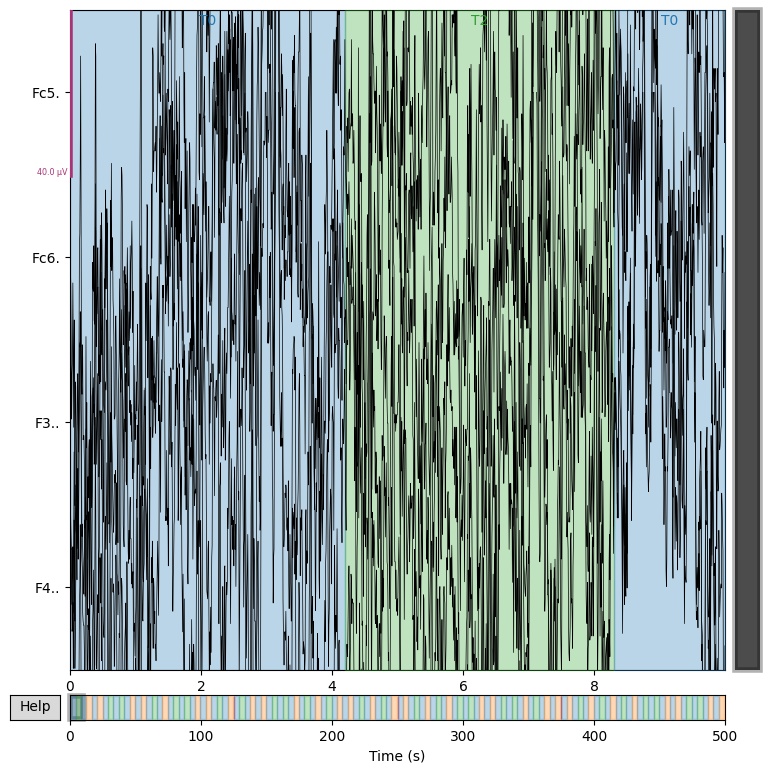

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


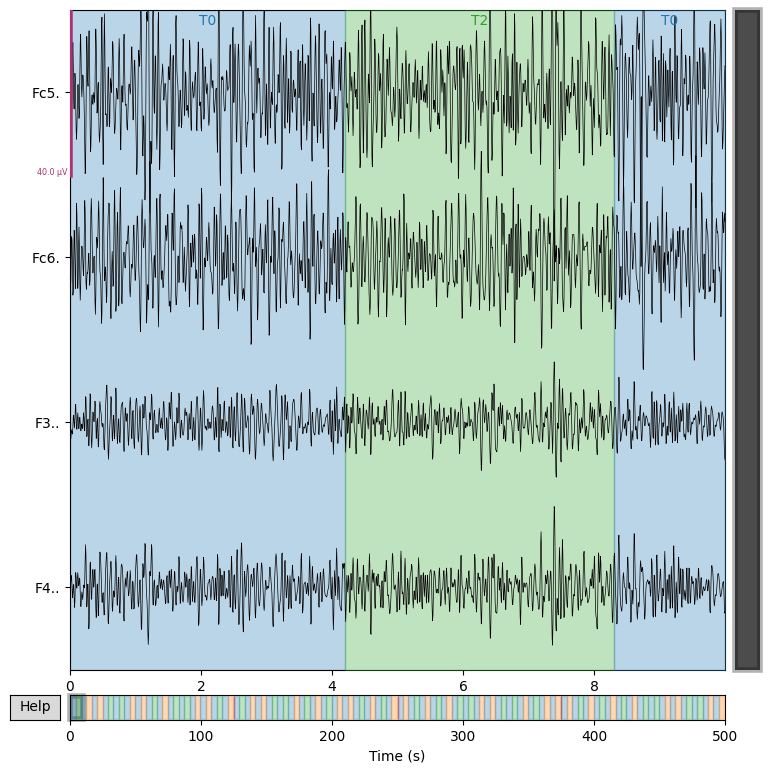

In [4]:
raw = mne.concatenate_raws([
    load_run(r"C:\Users\Tarun Kumar M\OneDrive\Documents\Sem 6\Major project\archive\files\S001\S001R03.edf"),
    load_run(r"C:\Users\Tarun Kumar M\OneDrive\Documents\Sem 6\Major project\archive\files\S001\S001R04.edf"),
    load_run(r"C:\Users\Tarun Kumar M\OneDrive\Documents\Sem 6\Major project\archive\files\S001\S001R07.edf"),
    load_run(r"C:\Users\Tarun Kumar M\OneDrive\Documents\Sem 6\Major project\archive\files\S001\S001R08.edf"),
], verbose=False)
#print(raw.ch_names)
raw.plot(title="Raw Signal")
plt.show()
   # see exactly what's available
#── Filter ────────────────────────────────────────────────────────────────
raw_filtered = raw.copy()
raw_filtered.filter(8.0, 30.0, method='fir', verbose=False)
raw_filtered.notch_filter(50, verbose=False)
raw_filtered.set_eeg_reference('average', projection=True)
raw_filtered.apply_proj()

raw_filtered.plot(title="Filtered Signal (8–30 Hz)")
plt.show()

Using channel: Fc5.


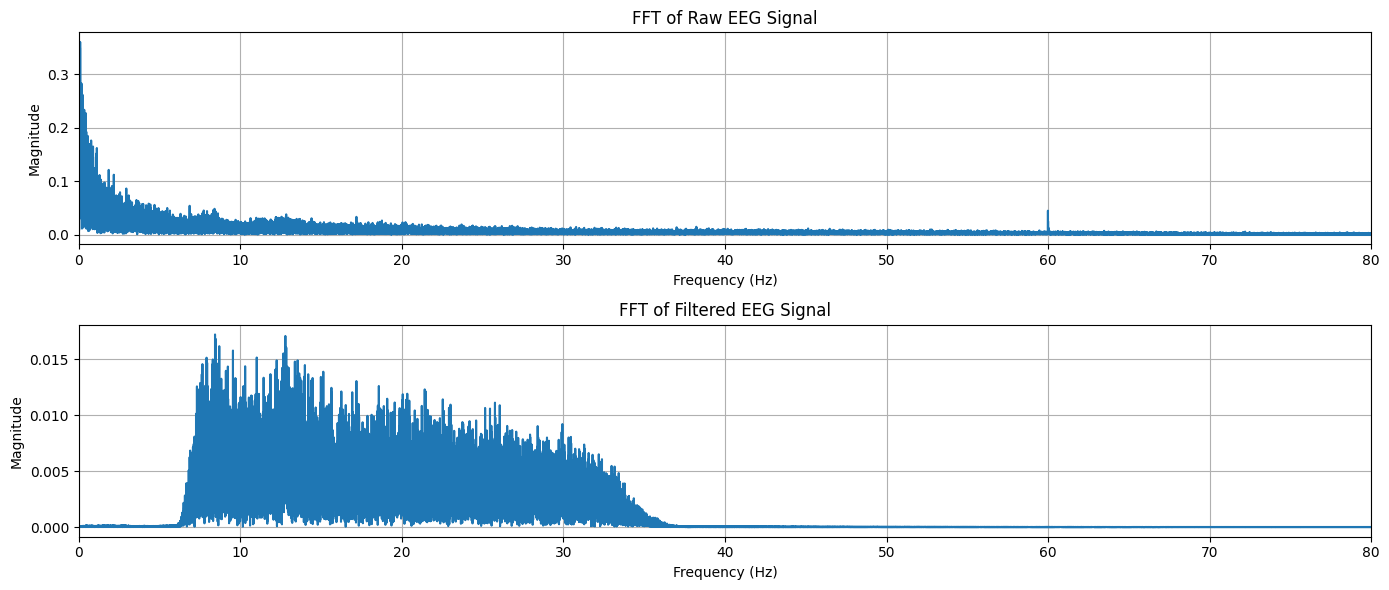

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# -----------------------------
# Select one EEG channel
# -----------------------------
channel_name = raw.ch_names[0]   # You can change this channel
print("Using channel:", channel_name)

# Raw signal
raw_data, times = raw[channel_name]

# Filtered signal
filtered_data, _ = raw_filtered[channel_name]

# Convert to 1D arrays
raw_signal = raw_data[0]
filtered_signal = filtered_data[0]

# Sampling frequency
fs = raw.info['sfreq']

# -----------------------------
# FFT for RAW signal
# -----------------------------
N = len(raw_signal)

raw_fft = fft(raw_signal)
freqs = fftfreq(N, d=1/fs)

# Keep only positive frequencies
positive = freqs >= 0

freqs_pos = freqs[positive]
raw_magnitude = np.abs(raw_fft[positive])

# -----------------------------
# FFT for FILTERED signal
# -----------------------------
filtered_fft = fft(filtered_signal)
filtered_magnitude = np.abs(filtered_fft[positive])

# -----------------------------
# Plot comparison
# -----------------------------
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(freqs_pos, raw_magnitude)
plt.xlim(0, 80)
plt.title("FFT of Raw EEG Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freqs_pos, filtered_magnitude)
plt.xlim(0, 80)
plt.title("FFT of Filtered EEG Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)

plt.tight_layout()
plt.show()

Event IDs found: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Epochs surviving rejection: 116
Idle:    56
Grasp:   32
Release: 28
Not setting metadata
116 matching events found
No baseline correction applied
0 projection items activated


C:\Users\Tarun Kumar M\AppData\Local\Temp\ipykernel_1052\1573788231.py:20: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs.plot_image(0)


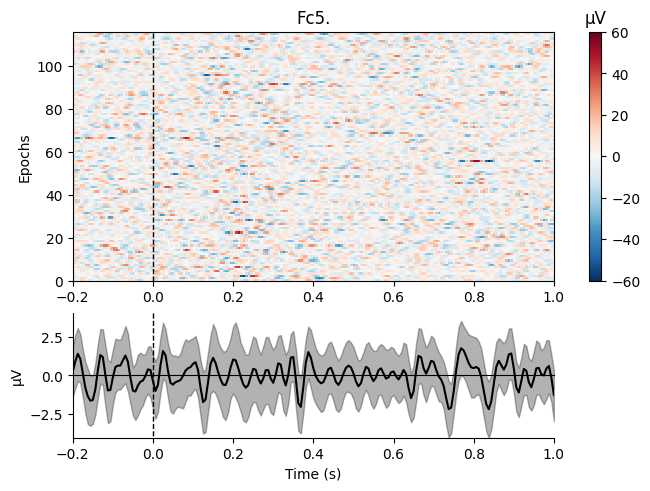

In [6]:
# ── Epoch ─────────────────────────────────────────────────────────────────
events, event_id = mne.events_from_annotations(raw_filtered, verbose=False)
print("Event IDs found:", event_id)

epochs = mne.Epochs(
    raw_filtered, events,
    event_id={'idle': event_id['T0'], 'grasp': event_id['T1'], 'release': event_id['T2']},
    tmin=-0.2, tmax=1.0,
    baseline=(-0.2, 0),
    preload=True,
    reject=dict(eeg=200e-6),
    verbose=False
)

print(f"Epochs surviving rejection: {len(epochs)}")
print(f"Idle:    {sum(epochs.events[:,2] == event_id['T0'])}")
print(f"Grasp:   {sum(epochs.events[:,2] == event_id['T1'])}")
print(f"Release: {sum(epochs.events[:,2] == event_id['T2'])}")

epochs.plot_image(0)
plt.show()


In [7]:
from scipy.signal import welch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [8]:

# # ── Feature Extraction ────────────────────────────────────────────────────
# def extract_features(epochs):
#     data = epochs.get_data()          # (n_epochs, 3, n_times)
#     sfreq = epochs.info['sfreq']
#     features = []
#     for epoch in data:
#         feats = []
#         for ch in epoch:
#             freqs, psd = welch(ch, fs=sfreq, nperseg=int(sfreq))
#             feats.append(np.mean(psd[(freqs >= 8)  & (freqs <= 12)]))  # mu power
#             feats.append(np.mean(psd[(freqs >= 13) & (freqs <= 30)]))  # beta power
#             feats.append(np.var(ch))                                     # variance
#         features.append(feats)
#     return np.array(features)   # (n_epochs, 9)

# X = extract_features(epochs)
# y = LabelEncoder().fit_transform(epochs.events[:, 2])
# print(f"X shape: {X.shape},  Class balance: {np.bincount(y)}")

# # ── Compare 3 models ──────────────────────────────────────────────────────
# models = {
#     'LDA': LinearDiscriminantAnalysis(),
#     'SVM': SVC(kernel='rbf', C=1.0),
#     'RF' : RandomForestClassifier(n_estimators=100, random_state=42),
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# print("\n── Cross-validation Results ──")
# for name, model in models.items():
#     pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
#     scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
#     print(f"{name:4s} → {scores.mean():.3f} ± {scores.std():.3f}")

# # ── Confusion matrix for best model (SVM) ────────────────────────────────
# X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# best = Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=1.0))])
# best.fit(X_tr, y_tr)

# print("\n", classification_report(y_te, best.predict(X_te), target_names=['grasp', 'release']))

# ConfusionMatrixDisplay.from_predictions(
#     y_te, best.predict(X_te),
#     display_labels=['grasp', 'release'],
#     cmap='Blues'
# )
# plt.title("Grasp vs Release — SVM")
# plt.tight_layout()
# plt.show()


X shape: (116, 44),  Class balance: [56 32 28]

── Feature Selection Results ──
k= 3 → 0.534 ± 0.032
k= 5 → 0.509 ± 0.072
k= 7 → 0.483 ± 0.076
k= 9 → 0.492 ± 0.084
k=12 → 0.492 ± 0.093

               precision    recall  f1-score   support

        idle       0.48      1.00      0.65        11
       grasp       1.00      0.14      0.25         7
     release       0.00      0.00      0.00         6

    accuracy                           0.50        24
   macro avg       0.49      0.38      0.30        24
weighted avg       0.51      0.50      0.37        24

              precision    recall  f1-score   support

        idle       0.55      0.88      0.68        56
       grasp       0.48      0.38      0.42        32
     release       0.00      0.00      0.00        28

    accuracy                           0.53       116
   macro avg       0.34      0.42      0.37       116
weighted avg       0.40      0.53      0.44       116



C:\Anaconda\envs\eeg\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Anaconda\envs\eeg\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Anaconda\envs\eeg\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


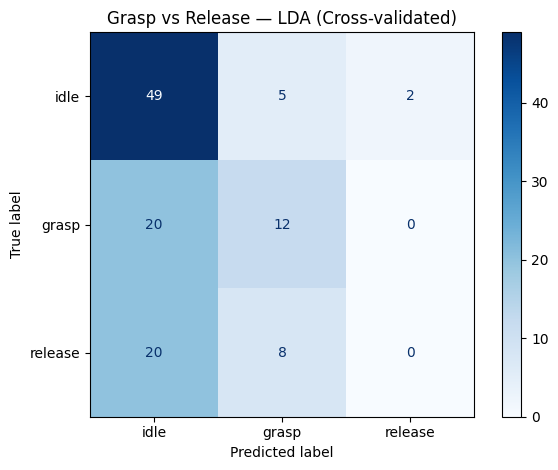

In [12]:
def extract_features(epochs):
    data = epochs.get_data()
    sfreq = epochs.info['sfreq']
    features = []
    for epoch in data:
        feats = []
        for ch in epoch:
            freqs, psd = welch(ch, fs=sfreq, nperseg=int(sfreq))

            # Your existing features
            feats.append(np.mean(psd[(freqs >= 8)  & (freqs <= 12)]))   # mu power
            feats.append(np.mean(psd[(freqs >= 13) & (freqs <= 30)]))   # beta power
            feats.append(np.var(ch))

            # ── New features ───────────────────────────────────────────
            feats.append(np.mean(psd[(freqs >= 4)  & (freqs <= 7)]))    # theta power
            feats.append(np.mean(psd[(freqs >= 30) & (freqs <= 45)]))   # gamma power
            feats.append(np.mean(ch))                                     # mean amplitude
            feats.append(np.std(ch))                                      # std deviation
            feats.append(np.max(np.abs(ch)))                              # peak amplitude

            # Hjorth parameters — measure signal complexity
            diff1 = np.diff(ch)
            diff2 = np.diff(diff1)
            activity   = np.var(ch)
            mobility   = np.sqrt(np.var(diff1) / activity)
            complexity = np.sqrt(np.var(diff2) / np.var(diff1)) / mobility
            feats.extend([activity, mobility, complexity])

        features.append(feats)
    return np.array(features)   # now (n_epochs, 33) instead of (n_epochs, 9)

X = extract_features(epochs)
y = LabelEncoder().fit_transform(epochs.events[:, 2])
print(f"X shape: {X.shape},  Class balance: {np.bincount(y)}")

# ── Compare 3 models ──────────────────────────────────────────────────────
from sklearn.feature_selection import SelectKBest, f_classif

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n── Feature Selection Results ──")
for k in [3, 5, 7, 9, 12]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(f_classif, k=k)),
        ('clf', LinearDiscriminantAnalysis())
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    print(f"k={k:2d} → {scores.mean():.3f} ± {scores.std():.3f}")

# ── Confusion matrix for best model (SVM) ────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
best = Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=1.0))])
best.fit(X_tr, y_tr)

print("\n", classification_report(y_te, best.predict(X_te), target_names=['idle','grasp', 'release']))

# ── Confusion matrix ──────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_predict

best = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(f_classif, k=3)),
    ('clf', LinearDiscriminantAnalysis())
])

# Uses all 60 epochs — much more reliable than 12 sample split
y_pred_cv = cross_val_predict(best, X, y, cv=StratifiedKFold(5))

print(classification_report(y, y_pred_cv, target_names=['idle','grasp', 'release']))

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_cv,
    display_labels=['idle','grasp', 'release'],
    cmap='Blues'
)
plt.title("Grasp vs Release — LDA (Cross-validated)")
plt.tight_layout()
plt.show()